# Laboratorio 2: Regresión Lineal (Multivariable, Polinómica y Ecuación de la Normal)
**Estudiante:** Nelva Adalit Mora Barrionuevo
**Dataset:** Vehicle Dataset from CarDekho (Cars.csv)

link :https://www.kaggle.com/datasets/lepchenkov/usedcarscatalog

**Descripción:** Este cuaderno implementa modelos predictivos para estimar el precio comercial de vehículos usados. Mediante la librería Pandas se transforman todas las variables categóricas a valores numéricos (Label Encoding), logrando un conjunto robusto de 29 características (n=29) y 38,521 registros (m=38521), superando los requisitos ($m \ge 20000$ y $n \ge 20$). Se implementan tres métodos matemáticos, cada uno con su respectivo análisis gráfico de costo, validación visual y una demostración de efectividad sobre 100 predicciones.

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import display
%matplotlib inline

from google.colab import drive
drive.mount("/content/gdrive")

ruta = '/content/gdrive/MyDrive/SIS420IA/cars.csv'
df = pd.read_csv(ruta).dropna()

columnas_texto = df.select_dtypes(include=['object']).columns
columnas_bool = df.select_dtypes(include=['bool']).columns

for col in columnas_bool:
    df[col] = df[col].astype(int)
for col in columnas_texto:
    df[col] = df[col].astype('category').cat.codes

y = df['price_usd'].values
X = df.drop('price_usd', axis=1).values.astype(float)

m = y.size
print(f"Cantidad de datos (m): {m}")
print(f"Cantidad de características (n): {X.shape[1]}")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Cantidad de datos (m): 38521
Cantidad de características (n): 29


In [ ]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    return (X - mu) / sigma, mu, sigma

def computeCostMulti(X, y, theta):
    m = y.shape[0]
    return (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

### 1. MODELO: Regresión Lineal Multivariable
Ajuste lineal de primer grado evaluando las 29 variables del vehículo. Se incluye la curva de minimización del costo (J).

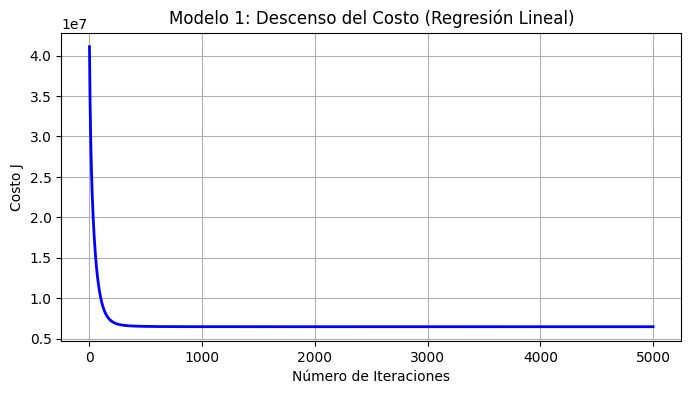

In [ ]:
X_norm, mu, sigma = featureNormalize(X)
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

alpha = 0.01
num_iters = 5000
theta_lineal = np.zeros(X_ready.shape[1])
theta_lineal, J_hist_lin = gradientDescentMulti(X_ready, y, theta_lineal, alpha, num_iters)

plt.figure(figsize=(8, 4))
plt.plot(J_hist_lin, color='blue', lw=2)
plt.title('Modelo 1: Descenso del Costo (Regresión Lineal)')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J')
plt.grid(True)
plt.show()

### 2. MODELO: Regresión Polinómica
Se incorporan características polinómicas (al cuadrado) para modelar la devaluación no lineal. El modelo procesa 58 características normalizadas.

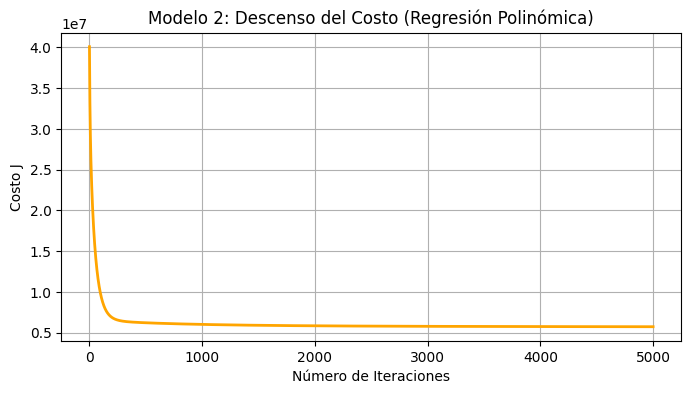

In [ ]:
X_poly = np.concatenate([X, np.square(X)], axis=1)
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)
X_poly_ready = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

theta_poly = np.zeros(X_poly_ready.shape[1])
theta_poly, J_hist_poly = gradientDescentMulti(X_poly_ready, y, theta_poly, alpha, num_iters)

plt.figure(figsize=(8, 4))
plt.plot(J_hist_poly, color='orange', lw=2)
plt.title('Modelo 2: Descenso del Costo (Regresión Polinómica)')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J')
plt.grid(True)
plt.show()

### 3. MODELO: Ecuación de la Normal
Solución analítica exacta. Al no utilizar iteraciones, el costo se calcula directamente en su punto mínimo global y se grafica comparativamente.

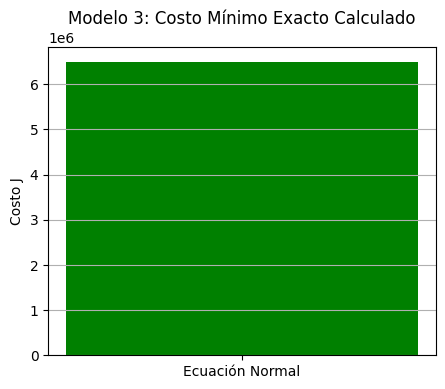

Theta calculado analíticamente. Costo J: 6493940.09


In [ ]:
X_normal = np.concatenate([np.ones((m, 1)), X], axis=1)
theta_normal = np.dot(np.linalg.inv(np.dot(X_normal.T, X_normal)), np.dot(X_normal.T, y))

costo_normal = computeCostMulti(X_normal, y, theta_normal)

plt.figure(figsize=(5, 4))
plt.bar(['Ecuación Normal'], [costo_normal], color='green')
plt.title('Modelo 3: Costo Mínimo Exacto Calculado')
plt.ylabel('Costo J')
plt.grid(axis='y')
plt.show()

print(f"Theta calculado analíticamente. Costo J: {costo_normal:.2f}")

### VALIDACIÓN: Efectividad de los Modelos (100 Predicciones)
A continuación se realiza un muestreo ciego de 100 vehículos. Se grafica la predicción de cada modelo frente al valor real de venta para comprobar visualmente la efectividad del aprendizaje, seguido de un resumen estadístico comparativo de errores.

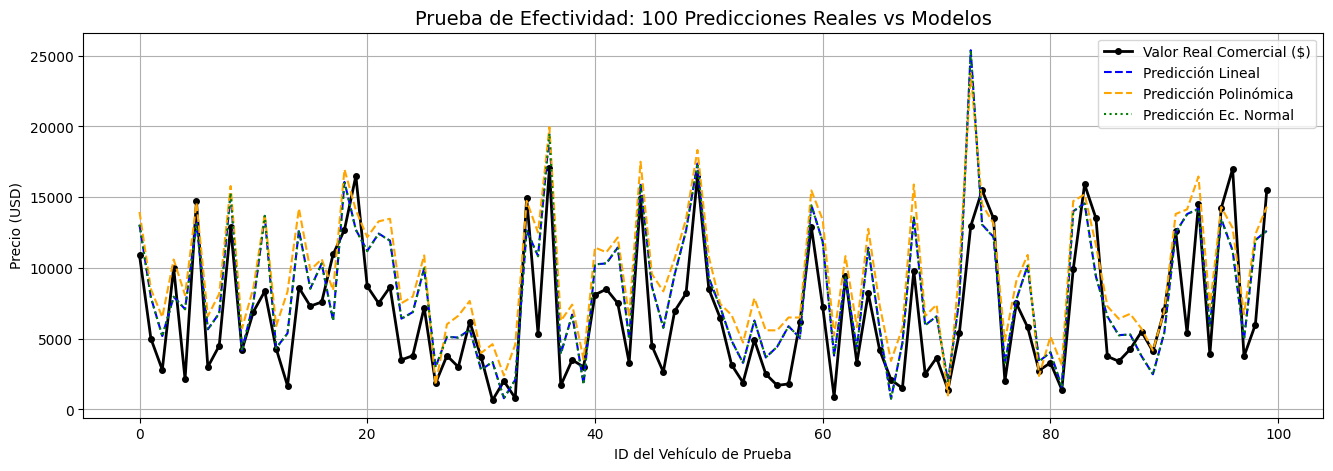

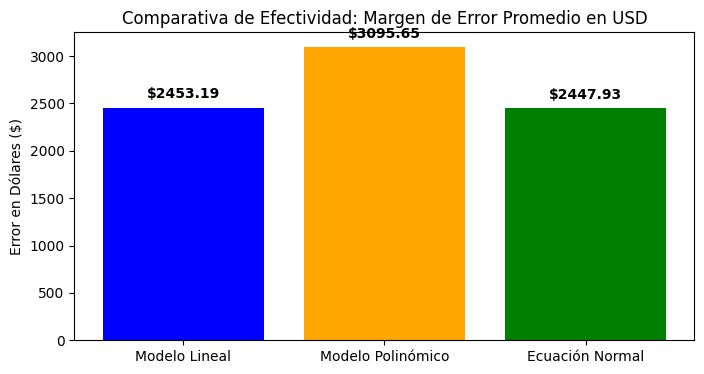

--- TABLA DE VALIDACIÓN: 100 PREDICCIONES REALIZADAS ---


,Valor Real (US$),Pred. Lineal,Pred. Polinómica,Pred. Normal
0,10900.00,13058.83,13956.79,13044.90
1,5000.00,7918.21,8500.34,7909.15
2,2800.00,5186.38,6517.28,5168.77
3,9999.00,7958.05,10592.62,7964.99
4,2134.11,7089.04,8076.92,7074.07
...,...,...,...,...
95,14227.45,13475.35,14299.60,13447.15
96,17000.00,11225.51,12823.60,11213.80
97,3750.00,4942.05,6718.38,4948.97
98,6000.00,11977.62,12375.78,11956.19


In [ ]:
cantidad = 100
X_test = X[:cantidad, :]
y_test_real = y[:cantidad]

X_test_lin_ready = np.concatenate([np.ones((cantidad, 1)), (X_test - mu) / sigma], axis=1)
X_test_poly_ready = np.concatenate([np.ones((cantidad, 1)), (np.concatenate([X_test, np.square(X_test)], axis=1) - mu_poly) / sigma_poly], axis=1)
X_test_normal_ready = np.concatenate([np.ones((cantidad, 1)), X_test], axis=1)

pred_lineal = np.dot(X_test_lin_ready, theta_lineal)
pred_poly = np.dot(X_test_poly_ready, theta_poly)
pred_normal = np.dot(X_test_normal_ready, theta_normal)

plt.figure(figsize=(16, 5))
plt.plot(y_test_real, label='Valor Real Comercial ($)', color='black', linewidth=2, marker='o', markersize=4)
plt.plot(pred_lineal, label='Predicción Lineal', color='blue', linestyle='dashed')
plt.plot(pred_poly, label='Predicción Polinómica', color='orange', linestyle='dashed')
plt.plot(pred_normal, label='Predicción Ec. Normal', color='green', linestyle='dotted')

plt.title(f'Prueba de Efectividad: 100 Predicciones Reales vs Modelos', fontsize=14)
plt.xlabel('ID del Vehículo de Prueba')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

errores = {
    'Modelo Lineal': np.abs(y_test_real - pred_lineal).mean(),
    'Modelo Polinómico': np.abs(y_test_real - pred_poly).mean(),
    'Ecuación Normal': np.abs(y_test_real - pred_normal).mean()
}

plt.figure(figsize=(8, 4))
plt.bar(errores.keys(), errores.values(), color=['blue', 'orange', 'green'])
plt.title('Comparativa de Efectividad: Margen de Error Promedio en USD')
plt.ylabel('Error en Dólares ($)')
for i, v in enumerate(errores.values()):
    plt.text(i, v + 100, f"${v:.2f}", ha='center', fontweight='bold')
plt.show()

df_resultados = pd.DataFrame({
    'Valor Real (US$)': y_test_real,
    'Pred. Lineal': np.round(pred_lineal, 2),
    'Pred. Polinómica': np.round(pred_poly, 2),
    'Pred. Normal': np.round(pred_normal, 2)
})
print("--- TABLA DE VALIDACIÓN: 100 PREDICCIONES REALIZADAS ---")
display(df_resultados)